# 03 - Recuperacion de precedentes similares

Este notebook implementa el modulo de busqueda de precedentes. La tarea es distinta de la clasificacion: no se decide que articulos activar, sino que se ordenan casos anteriores segun su similitud con una consulta.

La utilidad juridica es directa. Un abogado que estudia un caso nuevo no solo quiere una lista de articulos probables; tambien necesita localizar casos parecidos para revisar hechos, argumentos y lineas jurisprudenciales. Por eso se mide si los precedentes recuperados comparten articulos con la consulta.

Flujo del retrieval:

```text
caso de consulta
        ↓
TF-IDF con el mismo tipo de representacion textual
        ↓
similitud coseno contra casos de train
        ↓
ranking de precedentes
        ↓
evaluacion con Recall@5, Recall@10 y nDCG@10
```


In [1]:
from pathlib import Path
import json, sqlite3, random, warnings
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
ROOT = Path('..').resolve()
DATA = ROOT / 'data'
ARTIFACTS = ROOT / 'artifacts'
FIGURES = ARTIFACTS / 'figures'
METRICS = ARTIFACTS / 'metrics'
INDICES = ARTIFACTS / 'indices'
REPORTS = ARTIFACTS / 'reports'
DB = DATA / 'interim' / 'metadata.db'
for d in [FIGURES, METRICS, INDICES, REPORTS]:
    d.mkdir(parents=True, exist_ok=True)
def dump_json(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
import joblib


## Ejemplo minimo: ranking por similitud coseno

La similitud coseno compara direcciones de vectores, no longitud absoluta. Esto ayuda cuando un caso es mas largo que otro: si comparten terminos juridicos importantes, pueden quedar cerca aunque tengan distinto numero de palabras.


In [3]:
toy_precedents = pd.DataFrame({
    'case_id': ['precedent_1', 'precedent_2', 'precedent_3'],
    'text_full': [
        'detention fair trial applicant complaint',
        'private life family correspondence',
        'torture inhuman treatment detention',
    ],
    'labels': [{'5', '6'}, {'8'}, {'3', '5'}],
})
toy_query_text = 'applicant complained about detention and fair trial'
toy_query_labels = {'5', '6'}

toy_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
toy_X_prec = toy_vec.fit_transform(toy_precedents['text_full'])
toy_X_query = toy_vec.transform([toy_query_text])
toy_sims = cosine_similarity(toy_X_query, toy_X_prec).ravel()

toy_ranking = toy_precedents[['case_id', 'labels']].copy()
toy_ranking['cosine_similarity'] = toy_sims
toy_ranking['shares_article_with_query'] = toy_ranking['labels'].apply(lambda labs: int(len(labs & toy_query_labels) > 0))
toy_ranking = toy_ranking.sort_values('cosine_similarity', ascending=False)
display(toy_ranking)


,case_id,labels,cosine_similarity,shares_article_with_query
0,precedent_1,"{5, 6}",0.730556,1
2,precedent_3,"{5, 3}",0.105393,1
1,precedent_2,{8},0.000000,0


## Carga de casos y etiquetas

Cada consulta pertenece a `validation` o `test`; el indice de precedentes se construye sobre `train`. Esta separacion evita evaluar recuperando el propio caso o informacion futura.

La relevancia por articulos compartidos no pretende medir equivalencia juridica perfecta. Es una proxy razonable para un proyecto de ML: si dos casos activan los mismos articulos, es probable que compartan una problematica juridica util para busqueda inicial.


In [4]:
def load_cases(split):
    conn = sqlite3.connect(DB)
    df = pd.read_sql_query('SELECT case_id, text_full FROM cases WHERE split = ? ORDER BY case_id', conn, params=(split,))
    lab = pd.read_sql_query('SELECT cl.case_id, cl.article_id FROM case_labels cl JOIN cases c ON c.case_id = cl.case_id WHERE c.split = ? AND cl.value=1', conn, params=(split,))
    conn.close()
    labels = lab.groupby('case_id')['article_id'].apply(lambda s: set(map(str, s))).to_dict()
    df['labels'] = df['case_id'].map(lambda x: labels.get(x, set()))
    return df

train_full = load_cases('train')
val_full = load_cases('validation')
test_full = load_cases('test')
print('Dataset completo:', train_full.shape, val_full.shape, test_full.shape)


Dataset completo: (9000, 3) (1000, 3) (1000, 3)


## Muestras reproducibles

El corpus completo es manejable, pero limitar el numero de consultas hace que el notebook se ejecute de forma interactiva y estable. La muestra se fija con semilla para que los resultados sean comparables entre ejecuciones.

Esta decision debe explicarse con cuidado: la muestra acelera el notebook, pero no cambia la metodologia. Para resultados finales mas exhaustivos basta con aumentar `MAX_TRAIN_CASES` y `MAX_QUERY_CASES` o eliminar esos limites.


In [5]:
MAX_TRAIN_CASES = 2500
MAX_QUERY_CASES = 250
train = train_full.sample(n=min(MAX_TRAIN_CASES, len(train_full)), random_state=SEED).sort_values('case_id').reset_index(drop=True)
val = val_full.sample(n=min(MAX_QUERY_CASES, len(val_full)), random_state=SEED).sort_values('case_id').reset_index(drop=True)
test = test_full.sample(n=min(MAX_QUERY_CASES, len(test_full)), random_state=SEED).sort_values('case_id').reset_index(drop=True)
print('Muestra retrieval:', train.shape, val.shape, test.shape)


Muestra retrieval: (2500, 3) (250, 3) (250, 3)


## Metricas de ranking

Las metricas de retrieval no son las mismas que las de clasificacion:

- `Recall@5`: proporcion de consultas para las que aparece al menos un precedente relevante entre los 5 primeros.
- `Recall@10`: la misma idea con los 10 primeros resultados.
- `nDCG@10`: premia que los relevantes aparezcan arriba del ranking, no solo que aparezcan en algun lugar.

La relevancia se define como compartir al menos un articulo verdadero con la consulta. Es una aproximacion operativa: no demuestra que dos casos sean juridicamente identicos, pero si indica que pertenecen a una problematica cercana.


## Ejemplo minimo: Recall@k y nDCG@k

Si el ranking devuelve relevancias `[1, 0, 1, 0]`, hay precedentes utiles en las posiciones 1 y 3. Recall@1 ya acierta porque el primer resultado es relevante; nDCG premia que el primer relevante aparezca arriba.


In [6]:
def toy_recall_at_k(relevances, k):
    return int(np.sum(relevances[:k]) > 0)

def toy_ndcg_at_k(relevances, k):
    rels = np.asarray(relevances[:k], dtype=float)
    discounts = 1 / np.log2(np.arange(2, len(rels) + 2))
    dcg = np.sum(rels * discounts)
    ideal = np.sort(rels)[::-1]
    idcg = np.sum(ideal * discounts)
    return 0.0 if idcg == 0 else dcg / idcg

toy_relevances = [1, 0, 1, 0]
pd.DataFrame([{
    'ranking_relevances': str(toy_relevances),
    'recall_at_1': toy_recall_at_k(toy_relevances, 1),
    'recall_at_3': toy_recall_at_k(toy_relevances, 3),
    'ndcg_at_3': toy_ndcg_at_k(toy_relevances, 3),
}])


,ranking_relevances,recall_at_1,recall_at_3,ndcg_at_3
0,"[1, 0, 1, 0]",1,1,0.919721


In [7]:
def ndcg_binary(rels):
    rels = np.array(rels, dtype=float)
    if rels.sum() == 0:
        return 0.0
    discounts = 1.0 / np.log2(np.arange(2, len(rels)+2))
    dcg = float((rels * discounts).sum())
    ideal = np.sort(rels)[::-1]
    idcg = float((ideal * discounts).sum())
    return dcg / idcg if idcg else 0.0

def evaluate_retrieval(query_df, train_df, sim, top_k=10):
    rows = []
    recall5, recall10, ndcgs = [], [], []
    for i, q in query_df.reset_index(drop=True).iterrows():
        order = np.argsort(-sim[i])[:top_k]
        qlabs = q['labels']
        rels = [int(len(qlabs & train_df.iloc[j]['labels']) > 0) for j in order]
        for r, j in enumerate(order):
            rows.append({'query_case_id': q['case_id'], 'rank': r+1, 'retrieved_case_id': train_df.iloc[j]['case_id'], 'relevant': rels[r], 'score': float(sim[i, j])})
        recall5.append(int(any(rels[:5])))
        recall10.append(int(any(rels[:10])))
        ndcgs.append(ndcg_binary(rels[:10]))
    return {'n_queries': int(len(query_df)), 'n_queries_with_relevant': int(sum(recall10)), 'recall_at_5': float(np.mean(recall5)), 'recall_at_10': float(np.mean(recall10)), 'ndcg_at_10': float(np.mean(ndcgs))}, pd.DataFrame(rows)


## Retrieval TF-IDF + coseno

La similitud coseno compara la direccion de los vectores TF-IDF, no su longitud absoluta. Esto es adecuado para documentos de longitudes distintas: dos casos pueden ser parecidos aunque uno tenga muchos mas tokens.

TF-IDF es el baseline fuerte para retrieval textual porque es rapido, reproducible y facil de auditar. Si un caso se recupera por palabras juridicas muy genericas, esa limitacion aparecera en el analisis cualitativo y justifica explorar variantes densas.


In [8]:
vec = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True, max_features=60000)
X_train = vec.fit_transform(train['text_full'].fillna(''))
metrics_rows = []
ranking_frames = []
for split, df in [('validation', val), ('test', test)]:
    X_query = vec.transform(df['text_full'].fillna(''))
    sim = cosine_similarity(X_query, X_train)
    m, ranks = evaluate_retrieval(df, train, sim, top_k=10)
    m.update({'retrieval_method': 'tfidf_cosine_sampled', 'split': split})
    metrics_rows.append(m)
    ranks['split'] = split
    ranks['method'] = 'tfidf_cosine_sampled'
    ranking_frames.append(ranks)
joblib.dump({'vectorizer': vec, 'train_case_ids': train['case_id'].tolist(), 'note': 'sampled notebook index'}, INDICES / 'notebook_retrieval_tfidf_index.joblib')


['C:\\Users\\jordi\\Documents\\UNI\\juridico_ECtHR_B\\artifacts\\indices\\notebook_retrieval_tfidf_index.joblib']

## Variante densa ligera con SVD

La variante densa reduce el espacio TF-IDF con TruncatedSVD. No es una red neuronal ni un embedding semantico entrenado externamente; es una proyeccion lineal que concentra patrones de coocurrencia en menos dimensiones.

Su papel es comparar si una representacion mas compacta mejora el ranking o pierde informacion lexical importante. Esta comparacion es defendible porque mantiene reproducibilidad y no introduce modelos pesados dificiles de ejecutar.


In [9]:
n_components = min(64, X_train.shape[1]-1)
svd = TruncatedSVD(n_components=n_components, random_state=SEED)
Z_train = svd.fit_transform(X_train)
def norm_rows(Z):
    return Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-12)
Z_train = norm_rows(Z_train)
for split, df in [('validation', val), ('test', test)]:
    X_query = vec.transform(df['text_full'].fillna(''))
    Z_query = norm_rows(svd.transform(X_query))
    sim = Z_query.dot(Z_train.T)
    m, ranks = evaluate_retrieval(df, train, sim, top_k=10)
    m.update({'retrieval_method': 'tfidf_svd_cosine_sampled', 'split': split})
    metrics_rows.append(m)
    ranks['split'] = split
    ranks['method'] = 'tfidf_svd_cosine_sampled'
    ranking_frames.append(ranks)
joblib.dump({'svd': svd, 'train_case_ids': train['case_id'].tolist(), 'note': 'sampled notebook index'}, INDICES / 'notebook_retrieval_dense_index.joblib')


['C:\\Users\\jordi\\Documents\\UNI\\juridico_ECtHR_B\\artifacts\\indices\\notebook_retrieval_dense_index.joblib']

## Resultados y artefactos

El notebook guarda metricas agregadas y rankings por consulta. Los rankings permiten hacer analisis cualitativo: revisar casos donde el retrieval acierta, casos donde falla y posibles causas como vocabulario comun, articulos muy frecuentes o textos extremadamente largos.

La salida principal para el informe es `paper_retrieval_table.csv`, junto con la figura `paper_retrieval_recall10.png`.


In [10]:
retrieval = pd.DataFrame(metrics_rows)[['retrieval_method','split','n_queries','n_queries_with_relevant','ndcg_at_10','recall_at_5','recall_at_10']]
rankings = pd.concat(ranking_frames, ignore_index=True)
retrieval.to_csv(METRICS / 'paper_retrieval_table.csv', index=False)
retrieval.to_csv(METRICS / 'retrieval_tfidf_headline.csv', index=False)
rankings.to_csv(METRICS / 'retrieval_tfidf_rankings.csv', index=False)
dump_json({'stage': 'retrieval_notebook_sampled', 'max_train_cases': MAX_TRAIN_CASES, 'max_query_cases': MAX_QUERY_CASES, 'metrics': retrieval.to_dict(orient='records')}, REPORTS / 'retrieval_status.json')
retrieval


,retrieval_method,split,n_queries,n_queries_with_relevant,ndcg_at_10,recall_at_5,recall_at_10
0,tfidf_cosine_sampled,validation,250,241,0.882927,0.948,0.964
1,tfidf_cosine_sampled,test,250,242,0.867720,0.940,0.968
2,tfidf_svd_cosine_sampled,validation,250,240,0.891595,0.956,0.960
3,tfidf_svd_cosine_sampled,test,250,239,0.869793,0.928,0.956


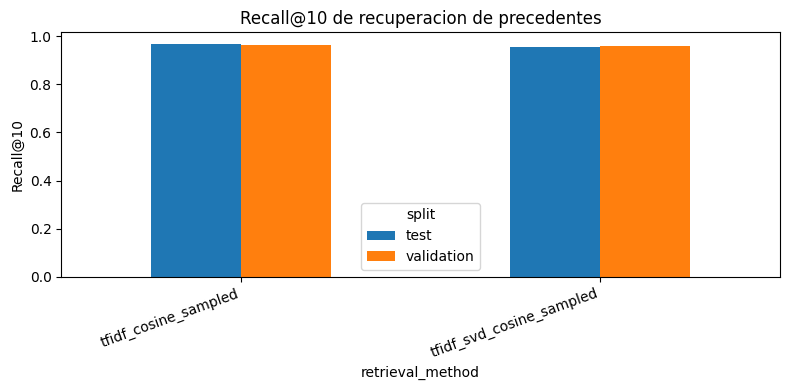

In [11]:
p = retrieval.pivot(index='retrieval_method', columns='split', values='recall_at_10')
ax = p.plot.bar(figsize=(8,4))
ax.set_title('Recall@10 de recuperacion de precedentes')
ax.set_ylabel('Recall@10')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIGURES / 'paper_retrieval_recall10.png', dpi=160)
